In [ ]:
from google.colab import files
files.upload()

Saving archive.zip to archive.zip
Buffered data was truncated after reaching the output size limit.

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Covid19-dataset/test/Covid/0100.jpeg  
  inflating: Covid19-dataset/test/Covid/0102.jpeg  
  inflating: Covid19-dataset/test/Covid/0105.png  
  inflating: Covid19-dataset/test/Covid/0106.jpeg  
  inflating: Covid19-dataset/test/Covid/0108.jpeg  
  inflating: Covid19-dataset/test/Covid/0111.jpg  
  inflating: Covid19-dataset/test/Covid/0112.jpg  
  inflating: Covid19-dataset/test/Covid/0113.jpg  
  inflating: Covid19-dataset/test/Covid/0115.jpeg  
  inflating: Covid19-dataset/test/Covid/0118.jpeg  
  inflating: Covid19-dataset/test/Covid/0119.jpeg  
  inflating: Covid19-dataset/test/Covid/0120.jpg  
  inflating: Covid19-dataset/test/Covid/094.png  
  inflating: Covid19-dataset/test/Covid/096.png  
  inflating: Covid19-dataset/test/Covid/098.jpeg  
  inflating: Covid19-dataset/test/Covid/COVID-00003b.jpg  
  inflating: Covid19-dataset/test/Covid/COVID-00012.jpg  
  inflating: Covid19-dataset/test/Covid/COVID-00022.jpg  
  inflating: Covid19-dataset/test

In [ ]:
!unzip -o archive.zip -d /content/

Archive:  archive.zip
  inflating: /content/Covid19-dataset/test/Covid/0100.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0102.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0105.png  
  inflating: /content/Covid19-dataset/test/Covid/0106.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0108.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0111.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0112.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0113.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0115.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0118.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0119.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0120.jpg  
  inflating: /content/Covid19-dataset/test/Covid/094.png  
  inflating: /content/Covid19-dataset/test/Covid/096.png  
  inflating: /content/Covid19-dataset/test/Covid/098.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/COVID-00003b.jpg  
  inf

In [ ]:
!ls

archive.zip	 covid_saved_model	final_model.h5
Covid19-dataset  covid_saved_model.zip	final_model.keras
covidapp.py	 data			sample_data


In [ ]:
!ls Covid19-dataset

test  train


In [ ]:
train_path = "/content/Covid19-dataset/train"
test_path  = "/content/Covid19-dataset/test"

In [ ]:
import os
print(os.listdir(train_path))

['Normal', 'Covid', 'Viral Pneumonia']


In [ ]:
import os
import shutil
import random

base_path = "/content/Covid19-dataset/train"

new_base = "/content/data"

os.makedirs(new_base + "/train", exist_ok=True)
os.makedirs(new_base + "/test", exist_ok=True)

classes = os.listdir(base_path)

for cls in classes:
    os.makedirs(new_base + "/train/" + cls, exist_ok=True)
    os.makedirs(new_base + "/test/" + cls, exist_ok=True)

    images = os.listdir(base_path + "/" + cls)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    test_imgs = images[split:]

    for img in train_imgs:
        shutil.copy(base_path + "/" + cls + "/" + img,
                    new_base + "/train/" + cls + "/" + img)

    for img in test_imgs:
        shutil.copy(base_path + "/" + cls + "/" + img,
                    new_base + "/test/" + cls + "/" + img)

print("✅ Dataset split done")

✅ Dataset split done


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report

train_path = "/content/data/train"
test_path = "/content/data/test"

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))

for layer in base.layers:
    layer.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(3, activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(train_data, epochs=15)

pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)

print(classification_report(test_data.classes, pred_classes))

Found 200 images belonging to 3 classes.
Found 51 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5850 - loss: 1.2658
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 901ms/step - accuracy: 0.7700 - loss: 0.5675
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 904ms/step - accuracy: 0.8350 - loss: 0.4074
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 897ms/step - accuracy: 0.8650 - loss: 0.3314
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 928ms/step - accuracy: 0.8550 - loss: 0.3432
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 608ms/step - accuracy: 0.8850 - loss: 0.3008
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 528ms/step - accuracy: 0.8900 - loss: 0.2685
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 606ms/step - accuracy: 0.8800 - loss: 0.3201
Epoch 9/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 523ms/step - accuracy: 0.9000 - loss: 0.2330
Epoch 10/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 545ms/step - accuracy: 0.9000 - loss: 0.2372
Epoch 

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam(model, img_array, last_conv_layer_name):

    img_tensor = tf.convert_to_tensor(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

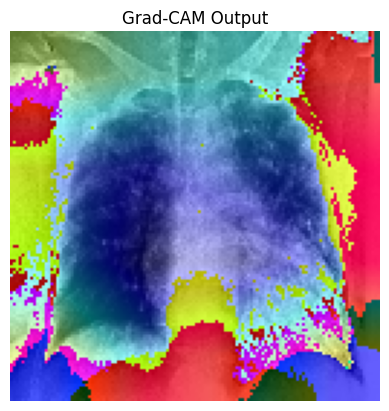

In [ ]:
img_path = test_data.filepaths[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (128,128))

img_array = np.expand_dims(img/255.0, axis=0)

heatmap = get_gradcam(model, img_array, "Conv_1")

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = heatmap * 0.4 + img

plt.imshow(superimposed.astype("uint8"))
plt.axis('off')
plt.title("Grad-CAM Output")
plt.show()

In [9]:
import os
print(os.listdir())

['.config', 'covidapp_all.py', 'covidapp.py', 'final_model.h5', 'sample_data']


In [10]:
from tensorflow.keras.models import load_model

model = load_model("final_model.h5", compile=False)
model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
model.save("final_model.h5")

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.3 MB/s eta 0:00:00


In [16]:
%%writefile covidapp_all.py
import os
import io
import numpy as np
import tensorflow as tf
import streamlit as st
from PIL import Image
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4

st.set_page_config(
    page_title="COVID-19 X-ray AI Detector",
    page_icon="🩺",
    layout="wide"
)

st.markdown("""
<style>
.stApp {
    background: linear-gradient(135deg, #eef2ff, #f8fafc, #e0f2fe);
}
.title {
    text-align:center;
    font-size:42px;
    font-weight:900;
    color:#0f172a;
}
.subtitle {
    text-align:center;
    color:#475569;
    font-size:17px;
}
.name {
    text-align:center;
    color:#2563eb;
    font-size:18px;
    font-weight:700;
    margin-bottom:20px;
}
.warning {
    background:#fff7ed;
    padding:15px;
    border-radius:15px;
    border-left:5px solid #f97316;
    color:#7c2d12;
    margin-bottom:20px;
}
.explain-box {
    background:#f8fafc;
    padding:18px;
    border-radius:15px;
    border-left:5px solid #2563eb;
    margin-top:15px;
}
.footer {
    text-align:center;
    color:#64748b;
    margin-top:30px;
}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_ai_model():
    model = tf.keras.models.load_model("final_model.h5", compile=False)
    return model

model = load_ai_model()

class_names = ["COVID", "Normal", "Viral Pneumonia"]
last_conv_layer_name = "out_relu"

def get_explanation(predicted_class):
    if predicted_class == "COVID":
        return {
            "title": "COVID-19 Infection Pattern",
            "effect": "COVID-19 may affect the lungs by causing inflammation in lung tissues and reducing normal air exchange.",
            "cause": "It is commonly caused by SARS-CoV-2 virus infection.",
            "xray": "In X-ray images, COVID-related changes may appear as cloudy or patchy lung regions.",
            "advice": "This is only an AI prediction. Doctor consultation and clinical tests are required for confirmation."
        }

    elif predicted_class == "Viral Pneumonia":
        return {
            "title": "Viral Pneumonia Pattern",
            "effect": "Viral pneumonia may affect the lungs by causing infection and inflammation in air sacs.",
            "cause": "It can be caused by respiratory viruses that infect the lungs.",
            "xray": "In X-ray images, pneumonia may show patchy opacities or abnormal lung shadows.",
            "advice": "This result should be confirmed by a healthcare professional."
        }

    else:
        return {
            "title": "Normal Chest X-ray Pattern",
            "effect": "The AI model did not detect strong COVID or pneumonia-like abnormal patterns.",
            "cause": "This suggests the uploaded X-ray appears closer to normal class based on training data.",
            "xray": "Normal X-rays usually show clear lung fields without major abnormal cloudy regions.",
            "advice": "If symptoms are present, consult a doctor even if AI prediction is normal."
        }

def predict_image(img):
    img_rgb = img.convert("RGB")
    img_resized = img_rgb.resize((128, 128))

    img_array = np.array(img_resized).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_index = int(np.argmax(prediction))
    predicted_class = class_names[predicted_index]
    confidence = float(np.max(prediction) * 100)

    return predicted_class, confidence, prediction, img_array

def make_gradcam(img, img_array):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return img.convert("RGB")

    heatmap = heatmap / max_value
    heatmap = heatmap.numpy()

    original = img.convert("RGB")

    heatmap_img = Image.fromarray(np.uint8(255 * heatmap))
    heatmap_img = heatmap_img.resize(original.size)
    heatmap_img = heatmap_img.convert("L")

    red_overlay = Image.new("RGB", original.size, (255, 0, 0))
    overlay = Image.composite(red_overlay, original, heatmap_img)
    overlay = Image.blend(original, overlay, alpha=0.35)

    return overlay

def create_pdf_report(predicted_class, confidence, prediction, explanation):
    buffer = io.BytesIO()

    pdf = canvas.Canvas(buffer, pagesize=A4)
    width, height = A4

    pdf.setFont("Helvetica-Bold", 18)
    pdf.drawString(50, height - 60, "COVID-19 X-ray AI Detection Report")

    pdf.setFont("Helvetica", 12)
    pdf.drawString(50, height - 105, f"Prediction: {predicted_class}")
    pdf.drawString(50, height - 130, f"Confidence: {confidence:.2f}%")

    pdf.drawString(50, height - 170, "Class Probabilities:")

    y = height - 195
    for i, name in enumerate(class_names):
        percent = float(prediction[0][i] * 100)
        pdf.drawString(70, y, f"{name}: {percent:.2f}%")
        y -= 25

    y -= 20
    pdf.setFont("Helvetica-Bold", 13)
    pdf.drawString(50, y, explanation["title"])

    pdf.setFont("Helvetica", 11)
    y -= 25
    pdf.drawString(50, y, f"Effect: {explanation['effect'][:90]}")
    y -= 20
    pdf.drawString(50, y, f"Cause: {explanation['cause'][:90]}")
    y -= 20
    pdf.drawString(50, y, f"X-ray Finding: {explanation['xray'][:90]}")
    y -= 20
    pdf.drawString(50, y, f"Note: {explanation['advice'][:90]}")

    pdf.setFont("Helvetica-Oblique", 10)
    pdf.drawString(
        50,
        80,
        "Disclaimer: This report is for educational/project purpose only. Not for real medical diagnosis."
    )

    pdf.drawString(
        50,
        55,
        "Developed by Priyadharshini | TensorFlow • CNN • Grad-CAM • Streamlit"
    )

    pdf.save()
    buffer.seek(0)

    return buffer

st.markdown('<div class="title">🩺 COVID-19 X-ray AI Detector</div>', unsafe_allow_html=True)
st.markdown('<div class="subtitle">Prediction + Grad-CAM + Explanation + PDF Report</div>', unsafe_allow_html=True)
st.markdown('<div class="name">👩‍💻 Developed by Priyadharshini</div>', unsafe_allow_html=True)

st.markdown("""
<div class="warning">
⚠️ This app is for educational/project purpose only. It is not a real medical diagnosis tool.
</div>
""", unsafe_allow_html=True)

st.sidebar.title("📌 Options")

app_mode = st.sidebar.radio(
    "Choose App Mode",
    ["Normal Prediction", "Prediction + Grad-CAM"]
)

image_mode = st.sidebar.radio(
    "Choose Image Source",
    ["Upload X-ray Image", "Use Sample Dataset Image"]
)

st.sidebar.markdown("---")
st.sidebar.success("Loaded Model Type: Keras")
st.sidebar.info("Grad-CAM Layer: out_relu")
st.sidebar.info("Input Size: 128 × 128")

selected_img = None
caption = ""

if image_mode == "Upload X-ray Image":

    uploaded_file = st.file_uploader(
        "Upload Chest X-ray Image",
        type=["jpg", "jpeg", "png"]
    )

    if uploaded_file is not None:
        selected_img = Image.open(uploaded_file)
        caption = "Uploaded X-ray"

else:

    category = st.selectbox(
        "Choose Category",
        ["Covid", "Normal", "Viral Pneumonia"]
    )

    sample_path = os.path.join(
        "archive",
        "Covid19-dataset",
        "test",
        category
    )

    if os.path.exists(sample_path):

        image_files = [
            f for f in os.listdir(sample_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if len(image_files) > 0:
            selected_file = st.selectbox("Choose X-ray Image", image_files)

            selected_img = Image.open(
                os.path.join(sample_path, selected_file)
            )

            caption = f"{category} / {selected_file}"

        else:
            st.error("No images found in this folder.")

    else:
        st.error("Dataset folder not found.")

if selected_img is not None:

    predicted_class, confidence, prediction, img_array = predict_image(selected_img)
    explanation = get_explanation(predicted_class)

    if app_mode == "Prediction + Grad-CAM":

        col1, col2 = st.columns(2)

        with col1:
            st.subheader("📷 Original X-ray")
            st.image(
                selected_img,
                caption=caption,
                use_column_width=True
            )

        with col2:
            st.subheader("🔥 Grad-CAM Overlay")
            gradcam_img = make_gradcam(selected_img, img_array)

            st.image(
                gradcam_img,
                caption="AI Focus Area",
                use_column_width=True
            )

    else:

        st.subheader("📷 X-ray Image")
        st.image(
            selected_img,
            caption=caption,
            use_column_width=True
        )

    st.markdown("---")

    st.subheader("🤖 AI Prediction Result")

    if predicted_class == "COVID":
        st.error(f"⚠️ Prediction: {predicted_class}")

    elif predicted_class == "Normal":
        st.success(f"✅ Prediction: {predicted_class}")

    else:
        st.warning(f"🟡 Prediction: {predicted_class}")

    st.info(f"Confidence: {confidence:.2f}%")
    st.progress(confidence / 100)

    st.write("### 📊 Class Probabilities")

    for i, name in enumerate(class_names):
        percent = float(prediction[0][i] * 100)
        st.write(f"{name}: {percent:.2f}%")
        st.progress(percent / 100)

    st.write("### 🧾 AI Explanation")

    st.markdown(f"""
    <div class="explain-box">
    <b>{explanation["title"]}</b><br><br>
    <b>How it may affect lungs:</b> {explanation["effect"]}<br><br>
    <b>Possible reason:</b> {explanation["cause"]}<br><br>
    <b>X-ray pattern:</b> {explanation["xray"]}<br><br>
    <b>Important note:</b> {explanation["advice"]}
    </div>
    """, unsafe_allow_html=True)

    pdf_file = create_pdf_report(
        predicted_class,
        confidence,
        prediction,
        explanation
    )

    st.download_button(
        label="📄 Download PDF Report",
        data=pdf_file,
        file_name="covid_xray_report.pdf",
        mime="application/pdf"
    )

else:
    st.info("Please upload or choose a sample X-ray image.")

st.markdown("""
<div class="footer">
🚀 Developed by Priyadharshini <br>
Built using TensorFlow • CNN • Grad-CAM • Streamlit • PDF Report
</div>
""", unsafe_allow_html=True)

Overwriting covidapp_all.py
